## Outline of ASDF Format

- Header containing metadata and structure information uses YAML
- Header followed by optionally 1 or more binary blocks
- Uses YAML Tags for type information
- Uses YAML anchors and aliases to share common elements.
- JSON Schema used for validation


## A Tour of the asdf-format organization on GitHub

The asdf-format organization on GitHub is where the majority of the ASDF related
repositories/packages are located. These include:

- [`asdf`](https://github.com/asdf-format/asdf)
  - The actual library.
- [`asdf-standard`](https://github.com/asdf-format/asdf-standard)
  - The base schemas and description of the functionality of asdf.
- [`asdf-transform-schemas`](https://github.com/asdf-format/asdf-transform-schemas)
  - The schemas for mathematical functions/models (typically for `astropy` models).
- [`asdf-coordinates-schemas`](https://github.com/asdf-format/asdf-coordinates-schemas)
  - The schemas for coordinates (typically `astropy` coordinates).
- [`asdf-wcs-schemas`](https://github.com/asdf-format/asdf-wcs-schemas)
  - The schemas for WCS objects (typically `gwcs` WCS).
- [`asdf-astropy`](https://github.com/astropy/asdf-astropy)
  - Not technically part of asdf-format, but maintained by ASDF maintainers as a
  collaboration with the astropy organization.
  - Contains schemas for some specialized `astropy` objects (not in the other packages).
  - Contains extensions for support of `astropy` objects.


See these repos for much more information, this notebook is based off much of the information they contain. You can download example data using the script in the roman-data-workshop repo

- https://github.com/asdf-format/scipy2022tutorial
- https://github.com/spacetelescope/roman-data-workshop/tree/main -> focused on roman data, and contains a script that will download some example roman files
- https://github.com/asdf-format/asdf-adass2024


#### Reading an ASDF file

The Python ASDF library is a standalone package distributed through PyPi and conda-forge.
you can read any asdf file by the library and return an object with a tree of information:


In [1]:
import asdf

To open a file use the `open` function. It is useful to look up the keyword arguments it accepts, there are options specifying in what mode a file should be opened or whether it should be validated during opening. For this example we will use the default behavior and look at the object.

In [2]:
pluto = asdf.open("pluto.asdf")
pluto

#### Getting information about a file

There are two functions that allow introspecting a file, `info` and `search`. They are available as methods on the `AsdfFile` object or and the command line interface. Both are configurable through multiple parameters.

In [3]:
pluto.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 2.12.0
├─history (dict)
│ └─extensions (list)
│   ├─[0] (ExtensionMetadata)
│   │ ├─extension_class (str): asdf.extension.BuiltinExtension
│   │ └─software (Software) ...
│   └─[1] (ExtensionMetadata)
│     ├─extension_class (str): asdf.extension._manifest.ManifestExtension
│     └─2 not shown
├─birthday (date): 1930-08-17
├─mass (Quantity): 10.0 kg
├─name (str): Pluto
└─picture (NDArrayType)
  ├─shape (tuple)
  │ ├─[0] (int): 333
  │ ├─[1] (int): 151
  │ └─[2] (int): 4
  └─dtype (Float32DType): float32
Some nodes not shown.


In [4]:
# you can search for metadata names
pluto.search("birthday")

root (AsdfObject)
└─birthday (date): 1930-08-17

In [5]:
# You can search for metadata values
pluto.search(value="Pluto")

root (AsdfObject)
└─name (str): Pluto

In [6]:
# You can also search for types of metadata, for example: astropy quantities
from astropy import units as u

pluto.search(type_=u.Quantity)

root (AsdfObject)
└─mass (Quantity): 10.0 kg

#### Accessing and Modifying a file

Attributes are accessed using a dict-like interface. Note that what we get below is a `Quantity` object.

In [7]:
weight = pluto["mass"]
print(weight)
type(weight)

10.0 kg


astropy.units.quantity.Quantity

Pluto


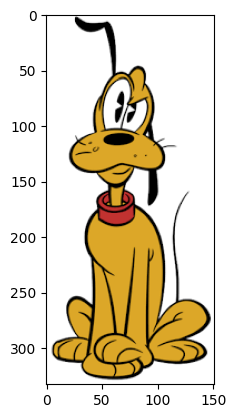

In [8]:
from matplotlib import pyplot as plt
print(pluto.tree['name'])
plt.imshow(pluto.tree['picture'])
pluto.close()

#### Using a schema to validate a file

ASDF uses schemas to check that a file conforms to the ASDF Standard and possibly the requirements of other extensions. jsonschema is used for validation. Schema validation happens on reading (asdf.open) and writing (write_to and update).

However, sometimes it is useful for particular applications to impose additional restrictions when deciding whether a given file is valid or not. ASDF allows using "custom schemas" in such cases and passing them to the open function.

Let's see how to write a schema and make sure our file `pluto.asdf` is correct.
*A schema is just a text file and and any editor can be used to write it.*

- There's a yaml header at the begining of each schema which states the version of the YAML schema, followed by `---` and the `$schema` declaration stating the draft.
- A schema file ends with `...` .
- The ASDF schemas use indentation, similar to YAML, and by convention it is 2 spaces.
- `title` is not required but by convention it's a one-line description of an attribute, printed as a comment by `info()`.
- `description` is an optional, longer, possibly multi-line comment.
- `type` is required
- If a `required` field is present, all properties listed in it must be present in the file.


In [9]:
s = """
%YAML 1.1
---
$schema: http://stsci.edu/schemas/yaml-schema/draft-01

title: Mickey's pet
description: |
  Basic info and a picture of Mickie's 
  dog Pluto.

type: object
properties:
  age:
    title: The age of Pluto
    type: object
    properties:
      birthday:
        title: Pluto's first showing
        tag: tag:stsci.edu:asdf/time/time-1.1.0
  mass:
    title: How much he weighs.
    tag: tag:stsci.edu:asdf/unit/quantity-1.1.0
  picture:
    tag: tag:stsci.edu:asdf/core/ndarray-1.0.0
  name:
    title: Name
    type: string
required: [name, picture]
...
"""

In [10]:
# we will create a new schema file and write the schema represented in the "s" string above
f = open("pluto-1.0.0.yaml", mode="w")
f.write(s)
f.close()

In [11]:
pluto=asdf.open("pluto.asdf", custom_schema="./pluto-1.0.0.yaml")

In [12]:
pluto.info()

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 2.12.0
├─history (dict)
│ └─extensions (list)
│   ├─[0] (ExtensionMetadata)
│   │ ├─extension_class (str): asdf.extension.BuiltinExtension
│   │ └─software (Software) ...
│   └─[1] (ExtensionMetadata)
│     ├─extension_class (str): asdf.extension._manifest.ManifestExtension
│     └─2 not shown
├─birthday (date): 1930-08-17
├─mass (Quantity): 10.0 kg
├─name (str): Pluto
└─picture (NDArrayType)
  ├─shape (tuple)
  │ ├─[0] (int): 333
  │ ├─[1] (int): 151
  │ └─[2] (int): 4
  └─dtype (Float32DType): float32
Some nodes not shown.


In [13]:
pluto.info(max_rows=30)  #to extend the information

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 2.12.0
├─history (dict)
│ └─extensions (list)
│   ├─[0] (ExtensionMetadata)
│   │ ├─extension_class (str): asdf.extension.BuiltinExtension
│   │ └─software (Software)
│   │   ├─name (str): asdf
│   │   └─version (str): 2.12.0
│   └─[1] (ExtensionMetadata)
│     ├─extension_class (str): asdf.extension._manifest.ManifestExtension
│     ├─extension_uri (str): asdf://asdf-format.org/core/extensions/core-1.5.0
│     └─software (Software)
│       ├─name (str): asdf-astropy
│       └─version (str): 0.2.1
├─birthday (date): 1930-08-17
├─mass (Quantity): 10.0 kg
├─name (str): Pluto
└─picture (NDArrayType)
  ├─shape (tuple)
  │ ├─[0] (int): 333
  │ ├─[1] (int): 151
  │ └─[2] (int): 4
  └─dtype (Float32DType): float32


In [14]:
pluto.tree['picture']

array([[[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       ...,

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.]],

       [[1., 1., 1., 1.],
        [1., 1., 1., 1.],
        [1., 1., 1., 1.],
        ...,
        [1., 1., 1., 1.],
        [1., 1.

In [15]:
del pluto.tree['picture']

In [16]:
pluto.info(max_rows=30)

root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 2.12.0
├─history (dict)
│ └─extensions (list)
│   ├─[0] (ExtensionMetadata)
│   │ ├─extension_class (str): asdf.extension.BuiltinExtension
│   │ └─software (Software)
│   │   ├─name (str): asdf
│   │   └─version (str): 2.12.0
│   └─[1] (ExtensionMetadata)
│     ├─extension_class (str): asdf.extension._manifest.ManifestExtension
│     ├─extension_uri (str): asdf://asdf-format.org/core/extensions/core-1.5.0
│     └─software (Software)
│       ├─name (str): asdf-astropy
│       └─version (str): 0.2.1
├─birthday (date): 1930-08-17
├─mass (Quantity): 10.0 kg
└─name (str): Pluto


In [17]:
pluto.write_to('bad_pluto.asdf')


ValidationError: 'picture' is a required property

Failed validating 'required' in schema:
    {'$schema': 'http://stsci.edu/schemas/yaml-schema/draft-01',
     'description': "Basic info and a picture of Mickie's \ndog Pluto.\n",
     'properties': {'age': {'properties': {'birthday': {'tag': 'tag:stsci.edu:asdf/time/time-1.1.0',
                                                        'title': "Pluto's "
                                                                 'first '
                                                                 'showing'}},
                            'title': 'The age of Pluto',
                            'type': 'object'},
                    'mass': {'tag': 'tag:stsci.edu:asdf/unit/quantity-1.1.0',
                             'title': 'How much he weighs.'},
                    'name': {'title': 'Name', 'type': 'string'},
                    'picture': {'tag': 'tag:stsci.edu:asdf/core/ndarray-1.0.0'}},
     'required': ['name', 'picture'],
     'title

## Objects Handled Intrinsically by ASDF

Recall that ASDF files store their information using a tree (nested key/value) structure.
This allows the stored information to be hierarchically organized with the file. Fundamentally,
this tree is a nested combination of basic structures:
- maps (forming the tree structure itself),
- lists,
- arrays,
- strings,
- booleans,
- and numbers.

All of which are stored using `yaml`. Note that more complex structures are denoted using
`yaml` tags, but those tagged structures are still comprised of the above basic structures,
and that these additional tagged objects are generally supported via ASDF extensions.

The Python analogs to these basic structures are:
- maps -> `dict`
- lists -> `list`
- arrays -> `np.ndarray`
- strings -> `str`
- booleans -> `bool`
- numbers -> `int`, `float`, `complex` (depending on type of number).

One special note is that although `yaml` supports a more general notion of what keys
are allowable within a map, the limitations of Python have restricted ASDF to only allowing
`bool`, `int`, or `str` types as keys.

## Building the Tree for a brand new object

To create an ASDF file, one must build a tree comprised of key/value pairs.
Typically, this takes the form of creating a Python `dict` which is then passed
to ASDF to be written to a file.

Let's start by creating a simple tree consisting of a `"hello": "world"` key/value
pair and then writing it to an ASDF file.

In [ ]:
tree = {"hello": "world"}
af = asdf.AsdfFile(tree)
af.write_to("hello.asdf")

In [ ]:
af=asdf.open("hello.asdf")

In [ ]:
af.info()

In [ ]:
af.close()

In [ ]:
tree = {
    "hello": "world",
    "foo": 42,
    "bar": 3.14,
    "true": False,
    "imaginary": complex(2, 3),
    "animals": ["cat", "dog", "bird"],
    "data": {"mean": 3.14, "std": 2.71},
}
af = asdf.AsdfFile(tree)
af.write_to("example.asdf")

In [ ]:
!cat example.asdf

## Serializing Everything Else

As mentioned above, other types of objects can also be serialized by ASDF, but these
objects are denoted in the `yaml` metadata via a `yaml` tag. Indeed some of the objects
already discussed are tagged in the metadata. Typically, these more complex objects
are supported via ASDF extensions, and when an extension which supports a particular object is installed, ASDF
will seamlessly serialize that object when it is placed within the ASDF tree.

In practice, this "seamless" interaction with the object is handled by the ASDF extension,
which will essentially specify a "sub-tree" (which is tagged by a `yaml` tag) which represents
that object, wherein the extension knows how to turn the object into that "sub-tree" and read
that "sub-tree" in order to reconstruct the object.

### Example - Serializing `astropy` Objects

The Roman pipeline makes extensive use of the `astropy` library, which includes several
objects that are useful to astronomical data. Due to this, the `asdf-astropy` extension
library provides extensions for most `astropy` objects to be serialized
and/or deserialized from ASDF files. Note that `asdf-astropy` is a dependency of the
Roman pipeline, so it will always be available for Roman ASDF work.

Currently `asdf-astropy` supports the following general object categories:

- `astropy` units and `quantities`.
- Most `astropy` models.
- `astropy` time objects.
- `astropy` coordinate objects.

For example, lets serialize `astropy`'s `Gaussian1D` model:

In [ ]:
import astropy.modeling.models as models

tree = {"gaussian": models.Gaussian1D(1, 2)}
af = asdf.AsdfFile(tree)
af.write_to("gaussian.asdf")

In [ ]:
f= asdf.open("gaussian.asdf")

In [ ]:
f.info()

In [ ]:
# because this is a gaussian object
f.tree['gaussian'].amplitude

In [ ]:
# you can evaluate it
f.tree['gaussian'](0.1)

### Serializing other astropy objects

In [ ]:
import astropy

quantity = 50 * astropy.units.m
model = astropy.modeling.models.Gaussian2D(quantity, 2, 3, 4, 5)
time = astropy.time.Time("J2000")
coord = astropy.coordinates.ICRS(ra=1 * astropy.units.deg, dec=2 * astropy.units.deg)

tree = {
    "quantity": quantity,
    "model": model,
    "time": time,
    "coord": coord,
}

af = asdf.AsdfFile(tree)
af.info()
af.write_to("astropy.asdf")
af.close()

Relation to Roman Data Models
------------------------------------------

Roman data files can be opened in two different ways. Directly in ASDF using `asdf.open` or through `roman_datamodels` through its `open` function. The roman_datamodels interface provides more functionality and conveniences, namely in returning a datamodels object and alowing use of dotted attribute notation for accessing items in the data set (as illustrated in tutorial (xxx link). For example in the above case the following would be relevant:

In [ ]:
import roman_datamodels as rdm
dm = rdm.open('r0000101001001001001_0001_wfi01_cal.asdf')
print('type of data model: ', type(dm))
print('shape of error array: ', dm.err.shape)
print('type of dm.meta.insrument: ', type(dm.meta.instrument))
print('optical_element = ', dm.meta.instrument.optical_element)

In [ ]:
dm.info()

In general, the Roman datamodel object classes are generated automatically from the schemas with a few exceptions, one of which is `WfiMode`. In that case an attribute `filter` is added to return the value of `optical_element` to provide consistency with JWST calibration code that is generic enough to share with Roman (and which is located in the stcal repository). In most cases each roman_datamodel node has an object type, but is basically a structure which has attributes as defined in the schema (which of course presumes that the attribute names are legal Python variable names). 

In [ ]:
dm.meta.exposure.start_time

In [ ]:
# look at the wcs information for the file
dm.meta.wcs

In [ ]:
dm.meta.wcs.available_frames

In [ ]:
#find some ra dec of some coordinates
dm.meta.wcs(100, 100)

In [ ]:
# does the pixel location roundtrip? mostly, you can get the specific reverse transform you want
w2pix = dm.meta.wcs.get_transform("world", "detector")
w2pix(269.9793884955382, 65.97726458574827)

In [ ]:
dm.meta.wcs.invert(269.9793884955382, 65.97726458574827) #or you can call the full invert

In [ ]:
d2v2v3 = dm.meta.wcs.get_transform("detector","v2v3") #this applies the distortion correction

In [ ]:
d2v2v3(100,100) # location in the distortion corrected frame, before v2v3 and velocity abberation applied

In [ ]:
# Create your own seperate gwcs object
from astropy.modeling import models
from astropy.modeling.models import Identity, Const1D, Mapping
from astropy import units as u
from astropy import coordinates as coord

import gwcs
from gwcs import coordinate_frames as cf

pixel_scale_x = 2
pixel_scale_y = 1
shiftx = 1
shifty = 0

shift = models.Shift(shiftx) & models.Shift(shifty)
scale = models.Scale(pixel_scale_x) & models.Scale(pixel_scale_y)
#affine = models.AffineTransformation2D( matrix=[[1, 0], [0, 1]], translation=[shiftx, shifty], name="rotation_matrix")

shift2det = shift | scale
shift2det.name = "Shift Transform to Gaia"
shift_frame = cf.Frame2D(name="ShiftFrame", axes_order=(0, 1),unit=(u.pix, u.pix))

sky_frame = cf.CelestialFrame( reference_frame=coord.FK5(), name="fk5", unit=(u.deg, u.deg))
pipeline = [ (shift_frame, shift2det), (sky_frame, None) ]    



In [ ]:
# Create your own seperate gwcs object
mywcs =gwcs.wcs.WCS(pipeline)

In [ ]:
mywcs.available_frames

In [ ]:
mywcs

In [ ]:
available_frames = dm.meta.wcs.available_frames
print(available_frames)

In [ ]:
# add your shift to an existing WCS
dm.meta.wcs.insert_transform('detector', shift2det, after=True)

In [ ]:
dm.meta.wcs #you should see your shift and scale as the first 4 elements now

In [ ]:
dm.meta.wcs(100,100) # and now you transform to a different sky location